# MERSCOPE: Microglia Trem2/Apoe Association Analysis

This notebook treats `sample_id` as a batch factor and asks a narrower question: which neighboring cell types are associated with higher or lower Trem2 and Apoe expression inside Microglia?

Because the MERSCOPE panel is limited, this is framed as an association problem, not causal proof. The main model uses Microglia-only cells, spatial neighbors from the `spatial` coordinates, and `sample_id` fixed effects to reduce batch bias.

In [37]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.spatial import cKDTree
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

In [38]:
ADATA_PATH = '/home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad'
SAMPLE_COL = 'sample_id'
CELLTYPE_COL = 'mannual_annotaion'
MICROGLIA_LABEL = 'Microglia'
TARGET_GENES = ['Trem2', 'Apoe']
N_NEIGHBORS = 12
MIN_CELLS_PER_SAMPLE = 20
MIN_VARIANCE = 1e-6

print('adata path:', ADATA_PATH)
print('sample column:', SAMPLE_COL)
print('cell type column:', CELLTYPE_COL)
print('target genes:', TARGET_GENES)
print('neighbors per cell:', N_NEIGHBORS)

adata path: /home/Data_Drive_8TB_2/kykim/potrai/MERSCOPE/after_bulk_ccf_annotated.h5ad
sample column: sample_id
cell type column: mannual_annotaion
target genes: ['Trem2', 'Apoe']
neighbors per cell: 12


In [39]:
adata = ad.read_h5ad(ADATA_PATH)
print(adata)

required = [SAMPLE_COL, CELLTYPE_COL, 'center_x', 'center_y']
missing = [c for c in required if c not in adata.obs.columns]
if missing:
    raise KeyError(f'Missing required obs columns: {missing}')

for g in TARGET_GENES:
    if g not in adata.var_names:
        raise KeyError(f'Missing target gene in var_names: {g}')

print('samples:', adata.obs[SAMPLE_COL].astype(str).nunique())
print('cell types:', adata.obs[CELLTYPE_COL].astype(str).nunique())
print('microglia cells:', int(adata.obs[CELLTYPE_COL].astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False).sum()))
print('obsm keys:', list(adata.obsm.keys()))
print('top cell types:')
display(adata.obs[CELLTYPE_COL].astype(str).value_counts().head(15).to_frame('n_cells'))

AnnData object with n_obs × n_vars = 136456 × 300
    obs: 'fov', 'center_x', 'center_y', 'x_min', 'x_max', 'y_min', 'y_max', 'volume', 'sample_id', 'genotype', 'strain', 'sex', 'age', 'region_location', 'region_short', 'trem2_mutation', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_300_genes', '_scvi_batch', '_scvi_labels', 'batch', 'dataset', 'class_pred', 'class_score', 'subclass_pred', 'subclass_score', 'supertype_pred', 'supertype_score', 'cluster_pred', 'cluster_score', 'final_label_transfer', 'leiden_res_0.50', 'leiden_res_0.75', 'leiden_res_1.00', 'leiden_res_1.25', 'leiden_res_0.10', 'leiden_res_0.25', 'Mannual_annotaion', 'mannual_annotaion', 'x_mosaic_px', 'y_mosaic_px', 'x_ccf_vox', 'y_ccf_vox', 'z_ccf_vox', 'ccf_reg_mode', 'cc

,n_cells
mannual_annotaion,
Glutamatergic_neuron,34891
Oligodendrocyte,31874
GABA_neuron,22163
Astrocyte,20314
Endothelial,10167
Microglia,9591
Pericyte,7109
Catecholaminergic_neuron,347


In [40]:
def to_dense(x):
    if sp.issparse(x):
        return x.toarray()
    return np.asarray(x)

def get_spatial_coords(adata_obj):
    if 'spatial' in adata_obj.obsm:
        return np.asarray(adata_obj.obsm['spatial'])
    return adata_obj.obs[['center_x', 'center_y']].to_numpy(dtype=float)

def is_microglia_series(series):
    return series.astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False)

coords = get_spatial_coords(adata)
print('spatial coords shape:', coords.shape)

obs = adata.obs[[SAMPLE_COL, CELLTYPE_COL, 'center_x', 'center_y']].copy()
obs['cell_id'] = adata.obs_names.astype(str).values
obs['is_microglia'] = is_microglia_series(obs[CELLTYPE_COL])

gene_expr = to_dense(adata[:, TARGET_GENES].X)
if gene_expr.ndim == 1:
    gene_expr = gene_expr.reshape(-1, 1)

obs['log1p_Trem2'] = np.log1p(gene_expr[:, TARGET_GENES.index('Trem2')])
obs['log1p_Apoe'] = np.log1p(gene_expr[:, TARGET_GENES.index('Apoe')])

spatial coords shape: (136456, 2)


In [41]:
microglia_rows = []
partner_types_global = sorted([t for t in obs[CELLTYPE_COL].astype(str).unique().tolist() if t.lower() != MICROGLIA_LABEL.lower()])

for sid, idx_labels in obs.groupby(SAMPLE_COL).groups.items():
    idx = obs.index.get_indexer(idx_labels)
    sub_obs = obs.iloc[idx].copy()
    sub_coords = coords[idx]
    sub_types = sub_obs[CELLTYPE_COL].astype(str).to_numpy()
    sub_expr = gene_expr[idx, :]

    tree = cKDTree(sub_coords)
    _, nn = tree.query(sub_coords, k=min(N_NEIGHBORS + 1, len(sub_coords)))
    if nn.ndim == 1:
        nn = nn[:, None]

    neighbor_idx = nn[:, 1:]
    micro_idx = np.where(sub_obs[CELLTYPE_COL].astype(str).str.contains(MICROGLIA_LABEL, case=False, regex=False).values)[0]
    if len(micro_idx) == 0:
        continue

    for i in micro_idx:
        nbr = neighbor_idx[i]
        nbr_types = pd.Series(sub_types[nbr]).value_counts()
        row = {
            'sample_id': str(sid),
            'cell_id': sub_obs.iloc[i]['cell_id'],
            'cell_type': sub_obs.iloc[i][CELLTYPE_COL],
            'n_neighbors': int(len(nbr)),
            'microglia_neighbor_fraction': float((sub_types[nbr] == MICROGLIA_LABEL).mean()),
            'log1p_Trem2': float(np.log1p(sub_expr[i, TARGET_GENES.index('Trem2')])),
            'log1p_Apoe': float(np.log1p(sub_expr[i, TARGET_GENES.index('Apoe')]))
        }
        for partner in partner_types_global:
            row[f'frac__{partner}'] = float(nbr_types.get(partner, 0) / len(nbr))
            row[f'count__{partner}'] = int(nbr_types.get(partner, 0))
        microglia_rows.append(row)

micro_df = pd.DataFrame(microglia_rows)
if micro_df.empty:
    raise RuntimeError('No microglia rows were created. Check spatial coordinates and labels.')

print('microglia rows:', len(micro_df))
print('samples in micro_df:', micro_df['sample_id'].nunique())
display(micro_df.head())

microglia rows: 9591
samples in micro_df: 4


,sample_id,cell_id,cell_type,n_neighbors,microglia_neighbor_fraction,log1p_Trem2,log1p_Apoe,frac__Astrocyte,count__Astrocyte,frac__Catecholaminergic_neuron,count__Catecholaminergic_neuron,frac__Endothelial,count__Endothelial,frac__GABA_neuron,count__GABA_neuron,frac__Glutamatergic_neuron,count__Glutamatergic_neuron,frac__Oligodendrocyte,count__Oligodendrocyte,frac__Pericyte,count__Pericyte
0,5xFAD1,5xFAD1_cell_in_reg_0_10_Z_0_fov_1928_1624804,Microglia,12,0.083333,2.064846,2.208248,0.166667,2,0.0,0,0.083333,1,0.000000,0,0.500000,6,0.166667,2,0.000000,0
1,5xFAD1,5xFAD1_cell_in_reg_0_21_Z_0_fov_1928_3151025,Microglia,12,0.083333,2.058793,2.157194,0.083333,1,0.0,0,0.166667,2,0.083333,1,0.333333,4,0.250000,3,0.000000,0
2,5xFAD1,5xFAD1_cell_in_reg_0_44_Z_0_fov_1928_3494498,Microglia,12,0.000000,2.068228,2.180942,0.000000,0,0.0,0,0.083333,1,0.166667,2,0.666667,8,0.083333,1,0.000000,0
3,5xFAD1,5xFAD1_cell_in_reg_0_53_Z_0_fov_1928_4531570,Microglia,12,0.000000,1.996459,2.061118,0.166667,2,0.0,0,0.083333,1,0.250000,3,0.250000,3,0.166667,2,0.083333,1
4,5xFAD1,5xFAD1_cell_in_reg_0_84_Z_0_fov_1928_8149195,Microglia,12,0.083333,2.077770,0.000000,0.083333,1,0.0,0,0.000000,0,0.000000,0,0.500000,6,0.333333,4,0.000000,0


In [42]:
micro_df['z_Trem2'] = micro_df.groupby('sample_id')['log1p_Trem2'].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0.0)
micro_df['z_Apoe'] = micro_df.groupby('sample_id')['log1p_Apoe'].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0.0)

partner_cols = [c for c in micro_df.columns if c.startswith('frac__')]
gene_map = {'Trem2': 'z_Trem2', 'Apoe': 'z_Apoe'}
results = []

for gene_name, response_col in gene_map.items():
    for partner_col in partner_cols:
        tmp = micro_df[[response_col, partner_col, 'n_neighbors', 'sample_id']].dropna().copy()
        if len(tmp) < MIN_CELLS_PER_SAMPLE * micro_df['sample_id'].nunique():
            continue
        if tmp[partner_col].nunique() < 2 or tmp[response_col].var(ddof=0) < MIN_VARIANCE:
            continue

        formula = f'{response_col} ~ {partner_col} + n_neighbors + C(sample_id)'
        fit = ols(formula, data=tmp).fit(cov_type='HC3')
        beta = float(fit.params.get(partner_col, np.nan))
        pval = float(fit.pvalues.get(partner_col, np.nan))

        per_sample_signs = []
        for sid, sub in tmp.groupby('sample_id'):
            if sub[partner_col].nunique() < 2 or sub[response_col].nunique() < 2:
                continue
            corr = sub[[response_col, partner_col]].corr(method='spearman').iloc[0, 1]
            if pd.notna(corr):
                per_sample_signs.append(np.sign(corr))

        signed_consistency = np.nan
        if per_sample_signs:
            signed_consistency = float(abs(np.sum(per_sample_signs)) / len(per_sample_signs))

        results.append({
            'gene': gene_name,
            'partner_type': partner_col.replace('frac__', ''),
            'beta': beta,
            'pvalue': pval,
            'n_cells': int(len(tmp)),
            'n_samples': int(tmp['sample_id'].nunique()),
            'signed_consistency': signed_consistency
        })

res = pd.DataFrame(results)
if res.empty:
    raise RuntimeError('No regression results were generated. Try lowering MIN_CELLS_PER_SAMPLE.')

res['fdr_bh'] = np.nan
for gene_name in gene_map:
    mask = res['gene'].eq(gene_name)
    pvals = res.loc[mask, 'pvalue'].to_numpy()
    if len(pvals) > 0:
        _, qvals, _, _ = multipletests(pvals, method='fdr_bh')
        res.loc[mask, 'fdr_bh'] = qvals

res = res.sort_values(['gene', 'fdr_bh', 'pvalue', 'beta'], ascending=[True, True, True, False])
display(res.head(30))

,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
11,Apoe,Glutamatergic_neuron,-0.726592,6.806012e-54,9591,4,1.000000,4.764208e-53
12,Apoe,Oligodendrocyte,0.622268,3.359626e-37,9591,4,1.000000,1.175869e-36
10,Apoe,GABA_neuron,0.148377,2.384734e-02,9591,4,0.000000,5.564379e-02
7,Apoe,Astrocyte,0.088288,2.203279e-01,9591,4,0.000000,3.855738e-01
9,Apoe,Endothelial,-0.136008,2.936575e-01,9591,4,0.500000,4.111205e-01
13,Apoe,Pericyte,0.084024,6.137084e-01,9591,4,1.000000,7.159931e-01
8,Apoe,Catecholaminergic_neuron,-0.283246,7.474185e-01,9591,4,0.333333,7.474185e-01
5,Trem2,Oligodendrocyte,0.194955,1.484245e-04,9591,4,1.000000,1.038971e-03
6,Trem2,Pericyte,-0.551023,3.251930e-03,9591,4,0.500000,1.138176e-02
4,Trem2,Glutamatergic_neuron,-0.115852,4.949596e-03,9591,4,0.500000,1.154906e-02


Top positive associations


,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
12,Apoe,Oligodendrocyte,0.622268,3.359626e-37,9591,4,1.000000,1.175869e-36
10,Apoe,GABA_neuron,0.148377,2.384734e-02,9591,4,0.000000,5.564379e-02
7,Apoe,Astrocyte,0.088288,2.203279e-01,9591,4,0.000000,3.855738e-01
13,Apoe,Pericyte,0.084024,6.137084e-01,9591,4,1.000000,7.159931e-01
5,Trem2,Oligodendrocyte,0.194955,1.484245e-04,9591,4,1.000000,1.038971e-03
3,Trem2,GABA_neuron,0.127187,3.787155e-02,9591,4,0.500000,6.627520e-02
1,Trem2,Catecholaminergic_neuron,0.322323,2.395896e-01,9591,4,0.333333,2.795212e-01
2,Trem2,Endothelial,0.101803,4.199259e-01,9591,4,1.000000,4.199259e-01


Top negative associations


,gene,partner_type,beta,pvalue,n_cells,n_samples,signed_consistency,fdr_bh
11,Apoe,Glutamatergic_neuron,-0.726592,6.806012e-54,9591,4,1.000000,4.764208e-53
9,Apoe,Endothelial,-0.136008,2.936575e-01,9591,4,0.500000,4.111205e-01
8,Apoe,Catecholaminergic_neuron,-0.283246,7.474185e-01,9591,4,0.333333,7.474185e-01
6,Trem2,Pericyte,-0.551023,3.251930e-03,9591,4,0.500000,1.138176e-02
4,Trem2,Glutamatergic_neuron,-0.115852,4.949596e-03,9591,4,0.500000,1.154906e-02
0,Trem2,Astrocyte,-0.119075,1.177979e-01,9591,4,0.000000,1.649171e-01


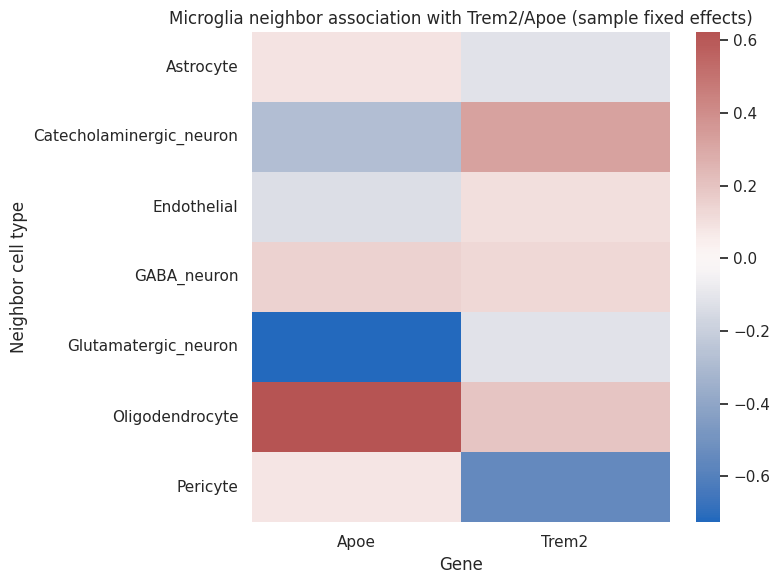

In [43]:
positive = res.query('beta > 0').sort_values(['gene', 'fdr_bh', 'beta'], ascending=[True, True, False])
negative = res.query('beta < 0').sort_values(['gene', 'fdr_bh', 'beta'], ascending=[True, True, True])

print('Top positive associations')
display(positive.groupby('gene').head(10))

print('Top negative associations')
display(negative.groupby('gene').head(10))

heat = res.pivot(index='partner_type', columns='gene', values='beta').fillna(0)
plt.figure(figsize=(8, max(6, 0.3 * len(heat))))
sns.heatmap(heat, cmap='vlag', center=0, annot=False)
plt.title('Microglia neighbor association with Trem2/Apoe (sample fixed effects)')
plt.xlabel('Gene')
plt.ylabel('Neighbor cell type')
plt.tight_layout()
plt.show()

In [44]:
OUT_CSV = 'microglia_neighbor_association_trem2_apoe.csv'
res.to_csv(OUT_CSV, index=False)
print('saved:', OUT_CSV)

saved: microglia_neighbor_association_trem2_apoe.csv


## How to read the result

- `beta > 0`: the partner cell type is associated with higher Microglia Trem2/Apoe.
- `beta < 0`: the partner cell type is associated with lower Microglia Trem2/Apoe.
- `fdr_bh < 0.05`: stronger candidate after multiple-testing correction.
- `signed_consistency` close to 1 means the sign is consistent across samples.

If you want a stricter version, the next step is to replace the single-partner regression with a multivariable model or a permutation test within each sample.